In [1]:
import numpy as np
from matplotlib import pyplot as plt
import os

In [2]:
out_dir = "../power_spectra/CO/20230313_no_std/"

with np.load(os.path.join(out_dir, "CV_0.npz"), allow_pickle=True) as data:
    curves = data['curves'].item()
    redshifts = data['redshifts'].item()
    ks = data['ks'].item()

In [22]:
print(np.argmax(~np.isnan(curves[0])))

24


0.17825912225678484
0.2244149388931896
0.2825216693588717
0.35567370893839306
0.44776667048962543
0.5637048400338547


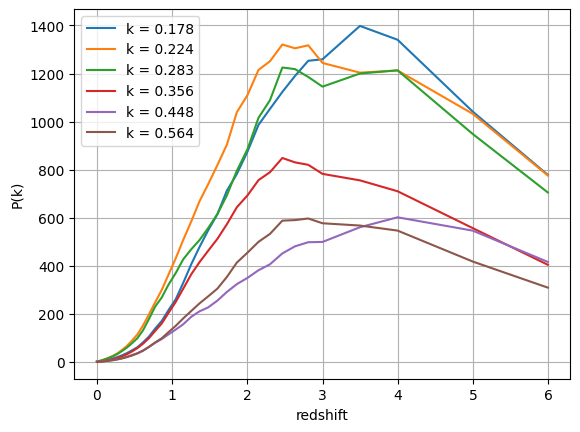

In [36]:
plt.figure()
plt.grid()
plt.xlabel("redshift")
plt.ylabel("P(k)")
for k_bin in range(24, 30):
    print(ks[0][k_bin])
    z_curve = []
    zs = []
    for snap_ind, redshift in redshifts.items():
        zs += [redshift]
        z_curve += [curves[snap_ind][k_bin]]
    plt.plot(zs, z_curve, label=f"k = {ks[0][k_bin]:.3f}")
# plt.yscale("log")
plt.legend()
plt.show()
plt.close()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


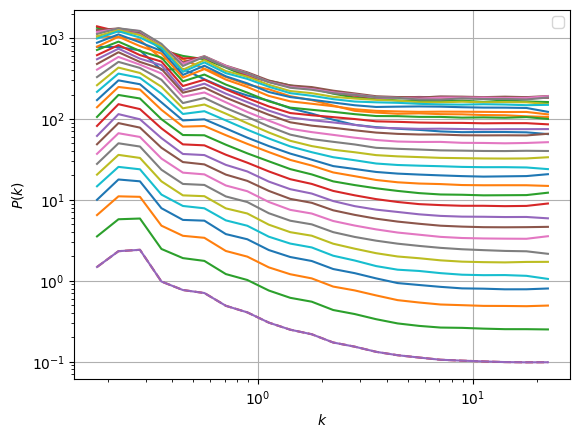

In [13]:
plt.figure()
plt.grid()
plt.loglog()
plt.xlabel(r"$k$")
plt.ylabel(r"$P(k)$")
for snap_ind in range(34):
    if snap_ind == 33:
        plt.plot(ks[snap_ind], curves[snap_ind], ls= "--")
    plt.plot(ks[snap_ind], curves[snap_ind], )
plt.xscale("log")
plt.legend()
plt.show()
plt.close()

In [23]:
curves[snap_ind][24:46]

array([1.47703677, 2.31812486, 2.40966928, 0.97697629, 0.76694975,
       0.70426979, 0.4895602 , 0.4059512 , 0.30325738, 0.24787697,
       0.21768707, 0.17212347, 0.15290754, 0.13200044, 0.11983744,
       0.11218185, 0.10534851, 0.10269141, 0.10043575, 0.09857348,
       0.09789508, 0.09810296])

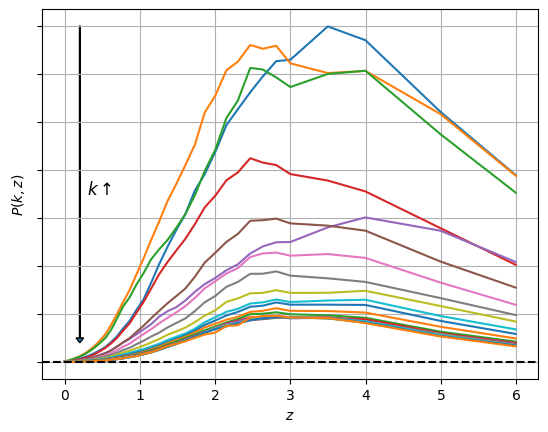

In [69]:
fig = plt.figure()
ax = plt.gca()
plt.grid()
plt.xlabel(r"$z$")
plt.ylabel("$P(k, z)$")
for k_bin in range(24, 46):
    # print(ks[0][k_bin])
    z_curve = []
    zs = []
    for snap_ind, redshift in redshifts.items():
        zs += [redshift]
        z_curve += [curves[snap_ind][k_bin]]
    plt.plot(zs, z_curve, label=f"k = {ks[0][k_bin]:.3f}")
# plt.yscale("log")
# plt.legend()
ax.set_yticklabels([])
ax.axhline(y=0, ls= "--", color="black")
plt.arrow(0.2, 1400, 0, -1300, width=0.01, head_width=0.1, head_length=20)
plt.text(0.3, 700, r"$k\uparrow$", fontsize=12)
plt.savefig("../plots/input.png", dpi=200)
plt.show()
plt.close()